# Mental Health Text Preprocessing for BERT

This notebook performs **production-grade preprocessing and exploratory analysis** for the mental health text dataset, preparing it for BERT-based modeling.

We focus **only on the text modality** and follow the existing project structure:
- Raw data: `data/raw/text/`
- Processed data: `data/processed/text/`
- Text configs and training scripts under `configs/`, `scripts/`, and `src/text/*`.

The notebook is organized into the following sections:
1. Environment setup
2. Load and validate dataset
3. Exploratory data analysis (EDA)
4. Text cleaning and normalization
5. Text construction for BERT
6. Train / validation / test split
7. Tokenization analysis
8. PyTorch dataset and dataloaders
9. Saving processed artifacts
10. Final preprocessing report

## Section 1 — Environment Setup

This section installs (if needed) and imports all required libraries, sets global random seeds for reproducibility, configures plotting styles, and prints library versions.

All paths are defined **relative to the project root** using `os.path.join` so the notebook is portable across environments.

In [1]:
import os
import re
import json
import random
import warnings
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

import torch
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from transformers import BertTokenizerFast

# Optional: be quiet
warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

SKLEARN_RANDOM_STATE = SEED

# Matplotlib / seaborn style
plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

# Project paths
PROJECT_ROOT = os.path.abspath(os.getcwd())

PROCESSED_TEXT_DIR = os.path.join(PROJECT_ROOT, "data", "processed", "text")
TOKENIZER_DIR = os.path.join(PROCESSED_TEXT_DIR, "tokenizer_config")

os.makedirs(PROCESSED_TEXT_DIR, exist_ok=True)
os.makedirs(TOKENIZER_DIR, exist_ok=True)

# ==============================
# OPTION 2 : DIRECT DATASET PATH
# ==============================

DATASET_PATH = r"C:\Users\Pratik Kale\Desktop\B-tech-model\interview-ai-detection\data\raw\text\mental_health_training_dataset.json"

if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(f"Dataset not found at: {DATASET_PATH}")

DATASET_VERSION = "manual_path"

print(f"Project root        : {PROJECT_ROOT}")
print(f"Processed text dir  : {PROCESSED_TEXT_DIR}")
print(f"Tokenizer dir       : {TOKENIZER_DIR}")
print(f"Dataset path        : {DATASET_PATH}")
print(f"Dataset version meta: {DATASET_VERSION}")
print("CUDA available      :", torch.cuda.is_available())

# Library versions
versions = {
    "python": f"{os.sys.version_info.major}.{os.sys.version_info.minor}.{os.sys.version_info.micro}",
    "torch": torch.__version__,
    "transformers": __import__("transformers").__version__,
    "sklearn": __import__("sklearn").__version__,
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "matplotlib": plt.matplotlib.__version__,
    "seaborn": sns.__version__,
}

print("\nLibrary versions:")
for k, v in versions.items():
    print(f"{k:12s}: {v}")

Project root        : c:\Users\Pratik Kale\Desktop\B-tech-model\interview-ai-detection\src\text\preprocessing
Processed text dir  : c:\Users\Pratik Kale\Desktop\B-tech-model\interview-ai-detection\src\text\preprocessing\data\processed\text
Tokenizer dir       : c:\Users\Pratik Kale\Desktop\B-tech-model\interview-ai-detection\src\text\preprocessing\data\processed\text\tokenizer_config
Dataset path        : C:\Users\Pratik Kale\Desktop\B-tech-model\interview-ai-detection\data\raw\text\mental_health_training_dataset.json
Dataset version meta: manual_path
CUDA available      : False

Library versions:
python      : 3.12.7
torch       : 2.10.0+cpu
transformers: 5.3.0
sklearn     : 1.8.0
pandas      : 3.0.1
numpy       : 1.26.4
matplotlib  : 3.10.8
seaborn     : 0.13.2


Project root        : c:\Users\Pratik Kale\Desktop\B-tech-model\interview-ai-detection\src\text\preprocessing
Processed text dir  : c:\Users\Pratik Kale\Desktop\B-tech-model\interview-ai-detection\src\text\preprocessing\data\processed\text
Tokenizer dir       : c:\Users\Pratik Kale\Desktop\B-tech-model\interview-ai-detection\src\text\preprocessing\data\processed\text\tokenizer_config
Dataset path        : C:\Users\Pratik Kale\Desktop\B-tech-model\interview-ai-detection\data\raw\text\mental_health_training_dataset.json
Dataset version meta: manual_path
CUDA available      : False

Library versions:
python      : 3.12.7
torch       : 2.10.0+cpu
transformers: 5.3.0
sklearn     : 1.8.0
pandas      : 3.0.1
numpy       : 2.4.2
matplotlib  : 3.10.8
seaborn     : 0.13.2


## Section 2 — Load and Validate Dataset

In this section we:
- Load `mental_health_training_dataset_v4.json` (or the fallback base file) from `data/raw/text/`.
- Flatten the four disease arrays (`depression`, `anxiety`, `ocd`, `adhd`) into a single `pandas.DataFrame`.
- Ensure the unified schema:
  - `sample_id`, `disease`, `label`,
  - `question_1`, `answer_1`, `question_2`, `answer_2`, ..., `question_5`, `answer_5` (interleaved).
- Run a set of **validation checks** and print a clear PASS/FAIL report.

In [2]:
# Load raw JSON
with open(DATASET_PATH, "r", encoding="utf-8") as f:
    raw_data = json.load(f)

metadata = raw_data.get("metadata", {})
DISEASES = ["depression", "anxiety", "ocd", "adhd"]

records = []

for disease in DISEASES:
    disease_samples = raw_data.get(disease, [])
    for sample in disease_samples:
        sample_id = sample.get("sample_id")
        label = sample.get("label")
        disease_name = sample.get("disease", disease)
        responses = sample.get("responses", [])

        # Expect 5 responses with question_id 1..5
        # Build maps to be robust to ordering
        q_map = {r.get("question_id"): r.get("question") for r in responses}
        a_map = {r.get("question_id"): r.get("answer") for r in responses}

        row = {
            "sample_id": sample_id,
            "disease": disease_name,
            "label": int(label) if label is not None else None,
        }

        for q_id in range(1, 6):
            row[f"question_{q_id}"] = q_map.get(q_id)
            row[f"answer_{q_id}"] = a_map.get(q_id)

        records.append(row)

# Create DataFrame with interleaved column order: question_1, answer_1, question_2, answer_2, ...
cols = ["sample_id", "disease", "label"] + [
    col
    for q_id in range(1, 6)
    for col in (f"question_{q_id}", f"answer_{q_id}")
]

df = pd.DataFrame(records)[cols]

print("DataFrame shape:", df.shape)
display(df.head())

DataFrame shape: (116, 13)


,sample_id,disease,label,question_1,answer_1,question_2,answer_2,question_3,answer_3,question_4,answer_4,question_5,answer_5
0,DEP_001,depression,1,Describe a recent situation that made you feel...,Last month I failed my UPSC prelims for the th...,How has your energy level affected your daily ...,I used to wake up at 6 AM for morning walk but...,Describe any changes you have noticed in your ...,I either sleep 12-14 hours or get no sleep at ...,How have these feelings affected your relation...,I stopped picking up calls from my friends. My...,Describe how your energy levels and motivation...,"Earlier I used to plan my whole day, make note..."
1,DEP_002,depression,1,Describe a recent situation that made you feel...,My marriage was fixed but the boy's family can...,How has your energy level affected your daily ...,I work in a BPO night shift. After shift I com...,Describe any changes you have noticed in your ...,I depend on sleeping tablets since last three ...,How have these feelings affected your relation...,I haven't visited my parents in Pune in four m...,Describe how your energy levels and motivation...,"I used to do zumba classes, had many hobbies. ..."
2,DEP_003,depression,1,Describe a recent situation that made you feel...,My startup failed after two years. I had taken...,How has your energy level affected your daily ...,"I was always energetic, used to go to gym. Now...",Describe any changes you have noticed in your ...,I wake up at 3 AM every night with heart racin...,How have these feelings affected your relation...,I shout at my children for small things and th...,Describe how your energy levels and motivation...,I had so many ideas before. Now my mind is bla...
3,DEP_004,depression,1,Describe a recent situation that made you feel...,My son moved to Canada for job. My husband pas...,How has your energy level affected your daily ...,"Earlier I used to cook, do puja, go for kitty ...",Describe any changes you have noticed in your ...,I eat very little. My daughter-in-law calls fr...,How have these feelings affected your relation...,My neighbor calls me for morning walk but I ma...,Describe how your energy levels and motivation...,"I used to be very active, organised Ganesh fes..."
4,DEP_005,depression,1,Describe a recent situation that made you feel...,I am in 12th standard and my parents keep comp...,How has your energy level affected your daily ...,I wake up tired even after sleeping 10 hours. ...,Describe any changes you have noticed in your ...,I eat food only when mother calls repeatedly. ...,How have these feelings affected your relation...,I don't talk to my parents much. I feel they a...,Describe how your energy levels and motivation...,I used to be so excited about learning. Now I ...


In [3]:
# Validation checks with PASS/FAIL report

validation_report = {}

# 1. Null / missing values
null_counts = df.isnull().sum()
validation_report["no_nulls"] = bool((null_counts == 0).all())

# 2. Exactly 5 responses per sample (all 5 answers non-null)
answer_cols = [f"answer_{i}" for i in range(1, 6)]
validation_report["exactly_5_responses"] = bool(df[answer_cols].notnull().all(axis=1).all())

# 3. Labels only 0 or 1
valid_labels = {0, 1}
unique_labels = set(df["label"].dropna().unique().tolist())
validation_report["labels_in_{0,1}"] = unique_labels.issubset(valid_labels)

# 4. Disease values only expected strings
unique_diseases = set(df["disease"].dropna().unique().tolist())
expected_diseases = set(DISEASES)
validation_report["diseases_expected"] = unique_diseases.issubset(expected_diseases)

# 5. sample_id uniqueness
validation_report["sample_id_unique"] = bool(df["sample_id"].is_unique)

print("Validation Report:\n" + "-" * 60)
for name, passed in validation_report.items():
    status = "PASS" if passed else "FAIL"
    print(f"{name:25s}: {status}")

print("\nDetails:")
print("Null counts per column:")
display(null_counts.to_frame(name="null_count"))
print("Unique labels:", unique_labels)
print("Unique diseases:", unique_diseases)
print("Total samples:", len(df))

Validation Report:
------------------------------------------------------------
no_nulls                 : PASS
exactly_5_responses      : PASS
labels_in_{0,1}          : PASS
diseases_expected        : PASS
sample_id_unique         : PASS

Details:
Null counts per column:


,null_count
sample_id,0
disease,0
label,0
question_1,0
answer_1,0
question_2,0
answer_2,0
question_3,0
answer_3,0
question_4,0


Unique labels: {0, 1}
Unique diseases: {'adhd', 'ocd', 'depression', 'anxiety'}
Total samples: 116


## Section 3 — Exploratory Data Analysis (EDA)

This section performs a comprehensive EDA:
- **3a. Basic statistics**: overall sample counts, per-disease counts, label distribution.
- **3b. Class balance analysis**: per-disease label counts, stacked bar charts, and minority-class warnings.
- **3c. Text length analysis**: word and character counts per answer and combined, with box plots per disease and per label.
- **3d. Vocabulary analysis**: token statistics, frequent words, per-disease vocabularies, and word clouds.
- **3e. Linguistic pattern analysis**: Indian English markers, first-person pronouns, negative sentiment words, hedging expressions.
- **3f. Inter-disease text similarity**: TF–IDF based cosine similarity across diseases.

In [4]:
# 3a. Basic statistics

eda_stats = {}

eda_stats["total_samples"] = int(len(df))
eda_stats["per_disease_counts"] = df["disease"].value_counts().to_dict()
eda_stats["label_distribution_overall"] = df["label"].value_counts().to_dict()

print("Basic dataset statistics:")
summary_table = pd.DataFrame({
    "count": df["disease"].value_counts(),
}).rename_axis("disease").reset_index()

label_overall = (
    df["label"].value_counts(normalize=False)
    .rename_axis("label")
    .reset_index(name="count")
)
label_overall["percentage"] = 100 * label_overall["count"] / label_overall["count"].sum()

display(summary_table)
print("\nOverall label distribution:")
display(label_overall)

Basic dataset statistics:


,disease,count
0,depression,50
1,anxiety,22
2,ocd,22
3,adhd,22



Overall label distribution:


,label,count,percentage
0,1,66,56.896552
1,0,50,43.103448


Label counts per disease:


label,0,1
disease,,
adhd,9,13
anxiety,9,13
depression,23,27
ocd,9,13


Label percentages per disease:


label,0,1
disease,,
adhd,40.91,59.09
anxiety,40.91,59.09
depression,46.00,54.00
ocd,40.91,59.09


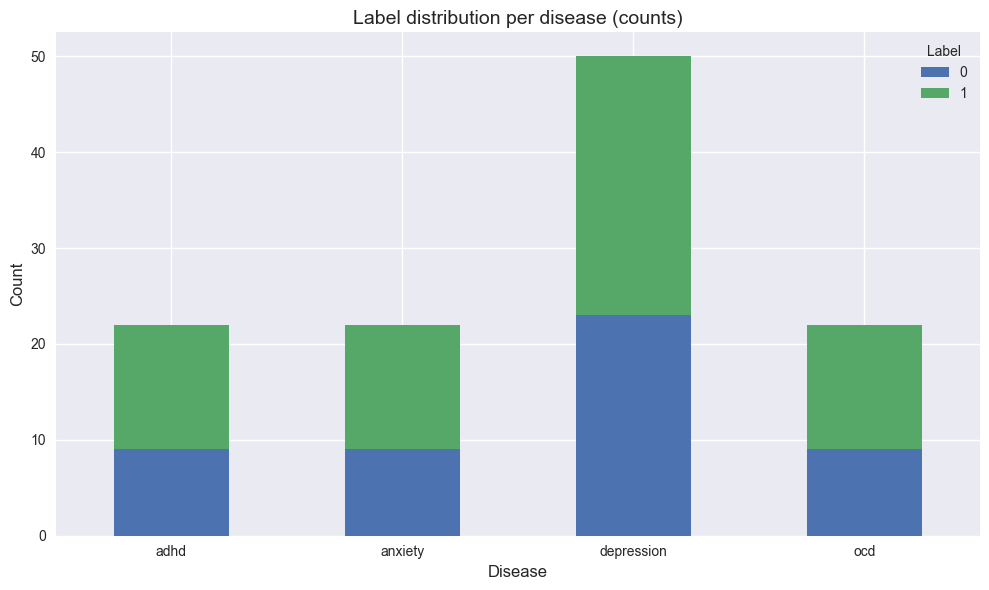


Class balance warnings:
  adhd       -> minority 40.9% (OK)
  anxiety    -> minority 40.9% (OK)
  depression -> minority 46.0% (OK)
  ocd        -> minority 40.9% (OK)


In [5]:
# 3b. Class balance analysis

label_counts_per_disease = (
    df.groupby(["disease", "label"]).size().unstack(fill_value=0)
)

# Store for stats export
eda_stats["label_counts_per_disease"] = {
    str(d): {str(l): int(c) for l, c in row.items()} for d, row in label_counts_per_disease.iterrows()
}

label_pct_per_disease = label_counts_per_disease.div(label_counts_per_disease.sum(axis=1), axis=0) * 100

print("Label counts per disease:")
display(label_counts_per_disease)

print("Label percentages per disease:")
display(label_pct_per_disease.round(2))

# Stacked bar chart
ax = label_counts_per_disease.plot(kind="bar", stacked=True)
ax.set_title("Label distribution per disease (counts)")
ax.set_ylabel("Count")
ax.set_xlabel("Disease")
plt.xticks(rotation=0)
plt.legend(title="Label")
plt.tight_layout()
plt.show()

# Minority class warning
print("\nClass balance warnings:")
for disease, row in label_pct_per_disease.iterrows():
    minority_pct = min(row.get(0, 0), row.get(1, 0))
    status = "OK"
    if minority_pct < 40:
        status = "WARNING: minority class < 40%"
    print(f"  {disease:10s} -> minority {minority_pct:.1f}% ({status})")

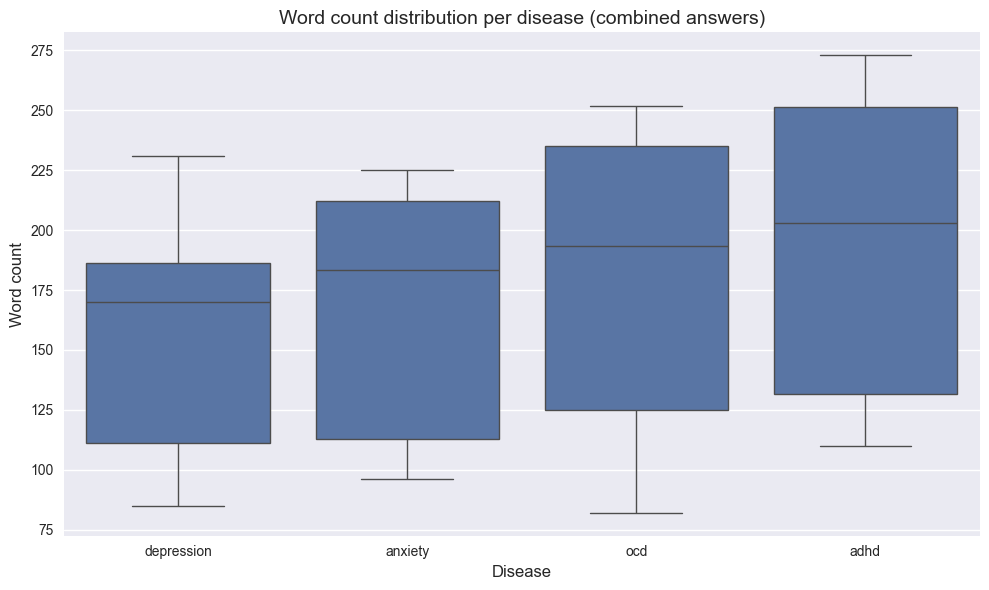

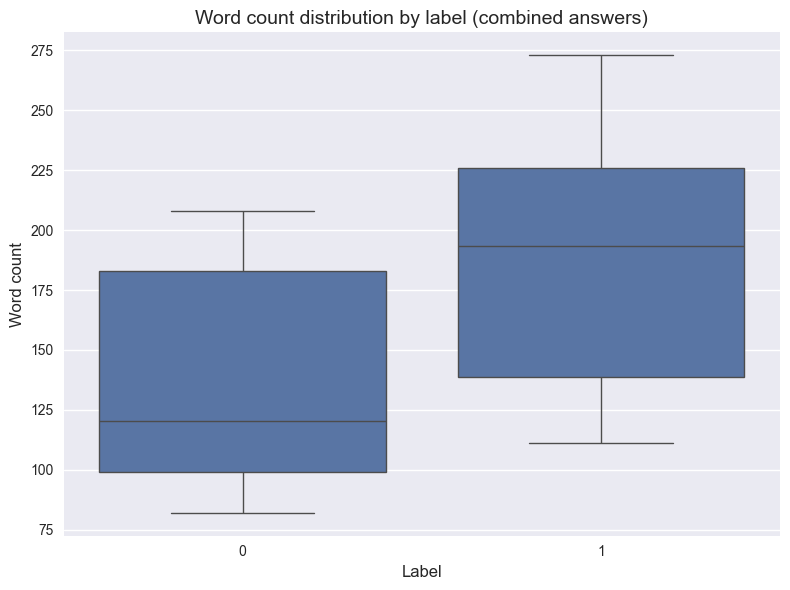

Text length statistics (combined answers, word counts) per disease:


,min,max,mean,median,std
disease,,,,,
adhd,110,273,189.50,203.0,61.81
anxiety,96,225,163.09,183.5,51.32
depression,85,231,156.74,170.0,42.33
ocd,82,252,174.59,193.5,62.34


In [6]:
# 3c. Text length analysis

# Compute per-answer and combined text
answer_cols = [f"answer_{i}" for i in range(1, 6)]

def safe_text(x: str) -> str:
    return x if isinstance(x, str) else ""

for col in answer_cols:
    df[f"{col}_words"] = df[col].fillna("").apply(lambda x: len(str(x).split()))
    df[f"{col}_chars"] = df[col].fillna("").apply(lambda x: len(str(x)))

# Combined all five answers
df["answers_combined"] = df[answer_cols].fillna("").agg(" ".join, axis=1).str.strip()
df["combined_words"] = df["answers_combined"].apply(lambda x: len(str(x).split()))
df["combined_chars"] = df["answers_combined"].apply(lambda x: len(str(x)))

# Box plots per disease
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="disease", y="combined_words")
plt.title("Word count distribution per disease (combined answers)")
plt.ylabel("Word count")
plt.xlabel("Disease")
plt.tight_layout()
plt.show()

# Box plots per label
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x="label", y="combined_words")
plt.title("Word count distribution by label (combined answers)")
plt.ylabel("Word count")
plt.xlabel("Label")
plt.tight_layout()
plt.show()

# Stats table: min, max, mean, median, std per disease
stats_per_disease = df.groupby("disease")["combined_words"].agg([
    "min", "max", "mean", "median", "std"
]).round(2)

eda_stats["text_length_per_disease"] = stats_per_disease.to_dict(orient="index")

print("Text length statistics (combined answers, word counts) per disease:")
display(stats_per_disease)

Total tokens:  19609
Unique tokens: 2526


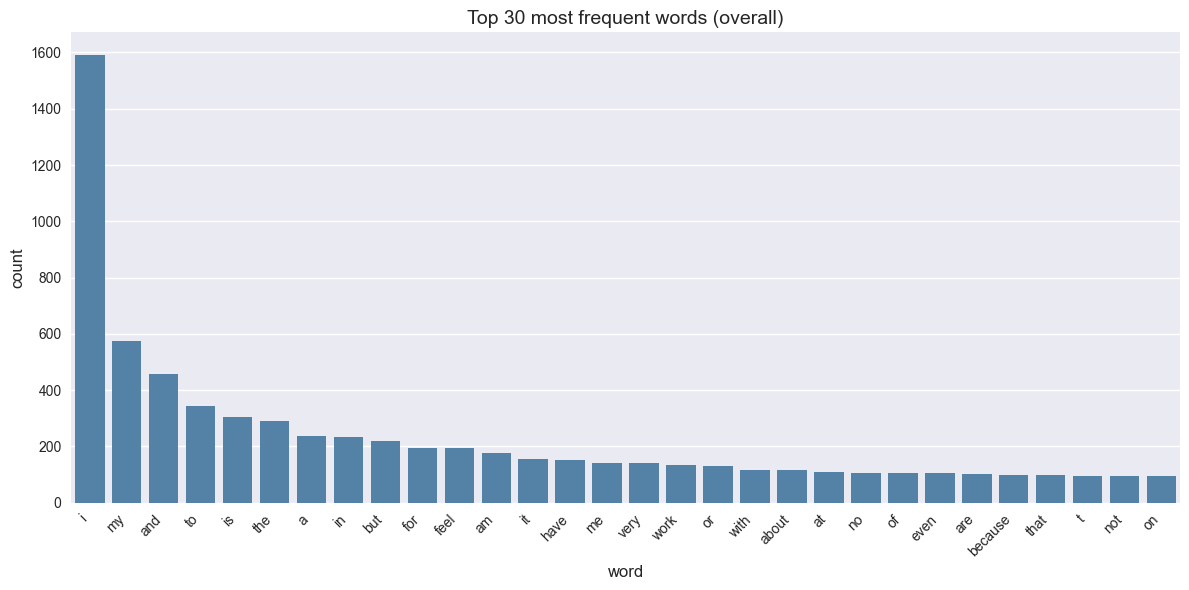

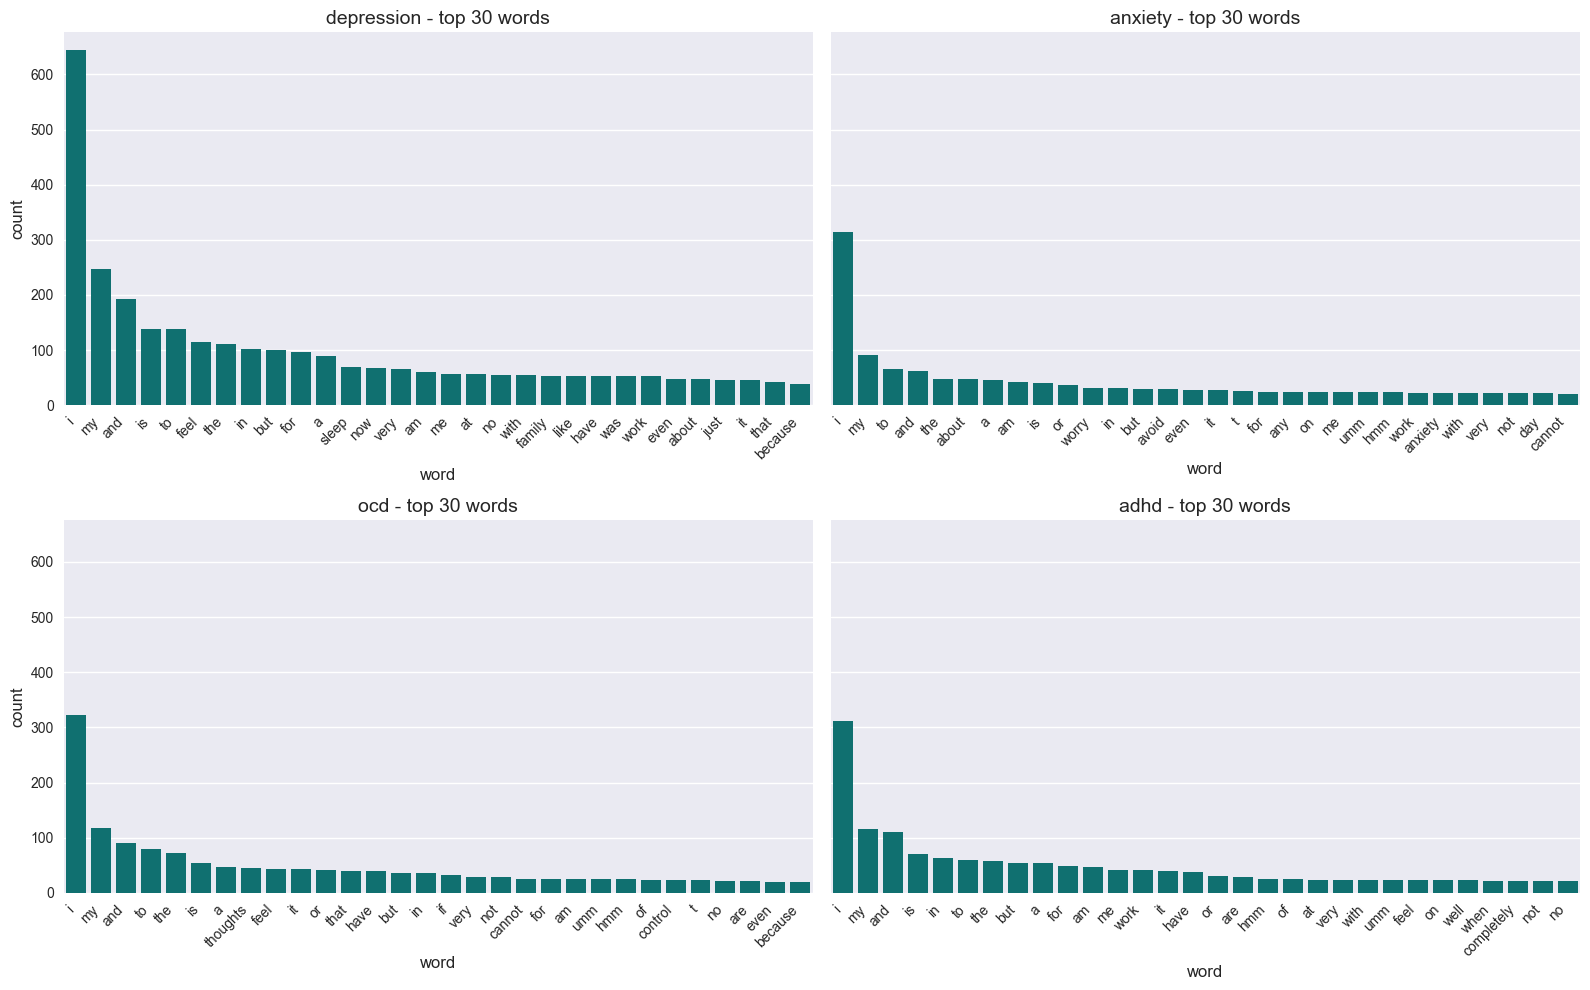

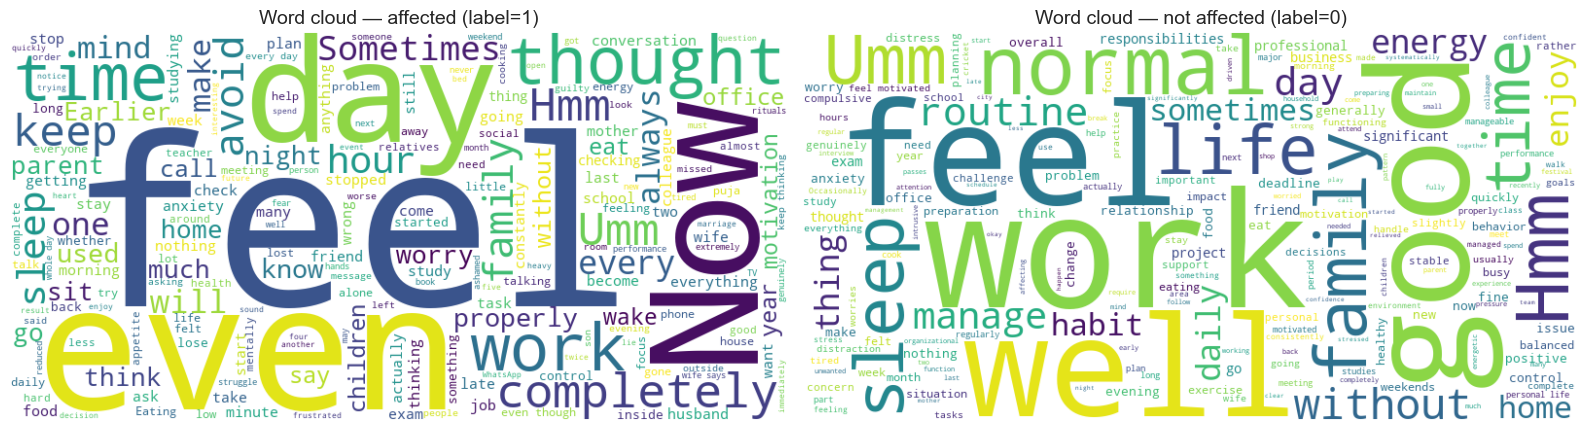

In [7]:
# 3d. Vocabulary analysis

TOKEN_PATTERN = re.compile(r"\b\w+\b", re.UNICODE)


def tokenize(text: str) -> list[str]:
    text = str(text).lower()
    return TOKEN_PATTERN.findall(text)


# Build overall vocabulary
all_tokens = []
for txt in df["answers_combined"].fillna("").tolist():
    all_tokens.extend(tokenize(txt))

vocab_counter = Counter(all_tokens)

total_tokens = int(sum(vocab_counter.values()))
unique_tokens = int(len(vocab_counter))

eda_stats["vocab_overall"] = {
    "total_tokens": total_tokens,
    "unique_tokens": unique_tokens,
}

print(f"Total tokens:  {total_tokens}")
print(f"Unique tokens: {unique_tokens}")

# Top 30 most frequent words (overall)
most_common_30 = vocab_counter.most_common(30)

freq_df = pd.DataFrame(most_common_30, columns=["word", "count"])
plt.figure(figsize=(12, 6))
sns.barplot(data=freq_df, x="word", y="count", color="steelblue")
plt.xticks(rotation=45, ha="right")
plt.title("Top 30 most frequent words (overall)")
plt.tight_layout()
plt.show()

# Top 30 per disease (subplot grid)
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=True)
axes = axes.flatten()

vocab_richness = {}

for idx, disease in enumerate(DISEASES):
    sub = df[df["disease"] == disease]
    tokens = []
    for txt in sub["answers_combined"].fillna("").tolist():
        tokens.extend(tokenize(txt))
    counter = Counter(tokens)
    total = int(sum(counter.values()))
    unique = int(len(counter))
    richness = unique / total if total > 0 else 0.0
    vocab_richness[disease] = {
        "total_tokens": total,
        "unique_tokens": unique,
        "richness": richness,
    }

    top_30 = counter.most_common(30)
    tmp_df = pd.DataFrame(top_30, columns=["word", "count"])

    ax = axes[idx]
    if not tmp_df.empty:
        sns.barplot(data=tmp_df, x="word", y="count", ax=ax, color="teal")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_title(f"{disease} - top 30 words")

plt.tight_layout()
plt.show()

eda_stats["vocab_richness_per_disease"] = vocab_richness

# Word clouds: affected vs not-affected
affected_text = " ".join(df.loc[df["label"] == 1, "answers_combined"].fillna("").tolist())
not_affected_text = " ".join(df.loc[df["label"] == 0, "answers_combined"].fillna("").tolist())

wc_affected = WordCloud(width=800, height=400, background_color="white").generate(affected_text)
wc_not_affected = WordCloud(width=800, height=400, background_color="white").generate(not_affected_text)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(wc_affected, interpolation="bilinear")
axes[0].set_title("Word cloud — affected (label=1)")
axes[0].axis("off")

axes[1].imshow(wc_not_affected, interpolation="bilinear")
axes[1].set_title("Word cloud — not affected (label=0)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

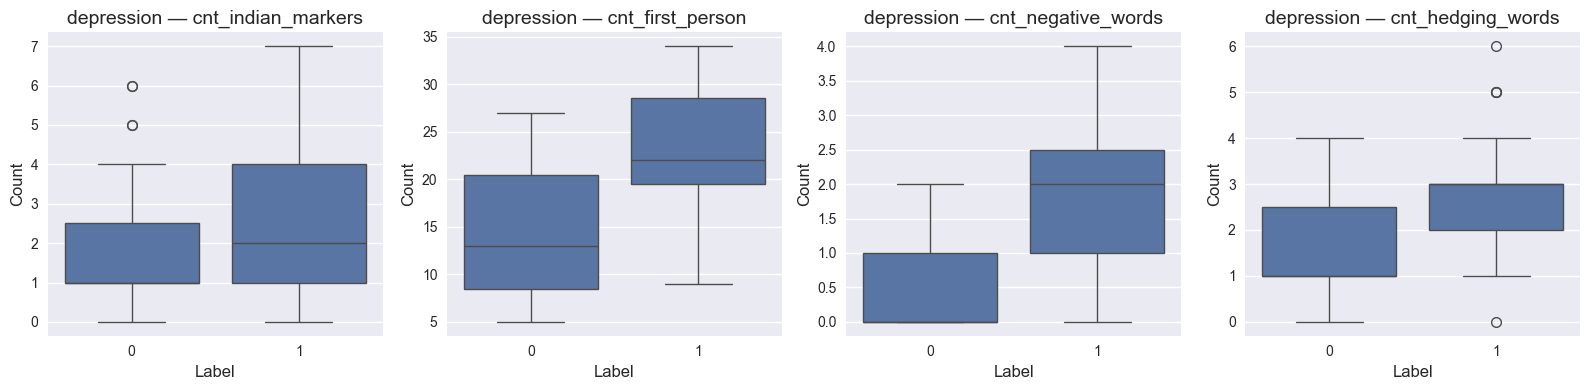

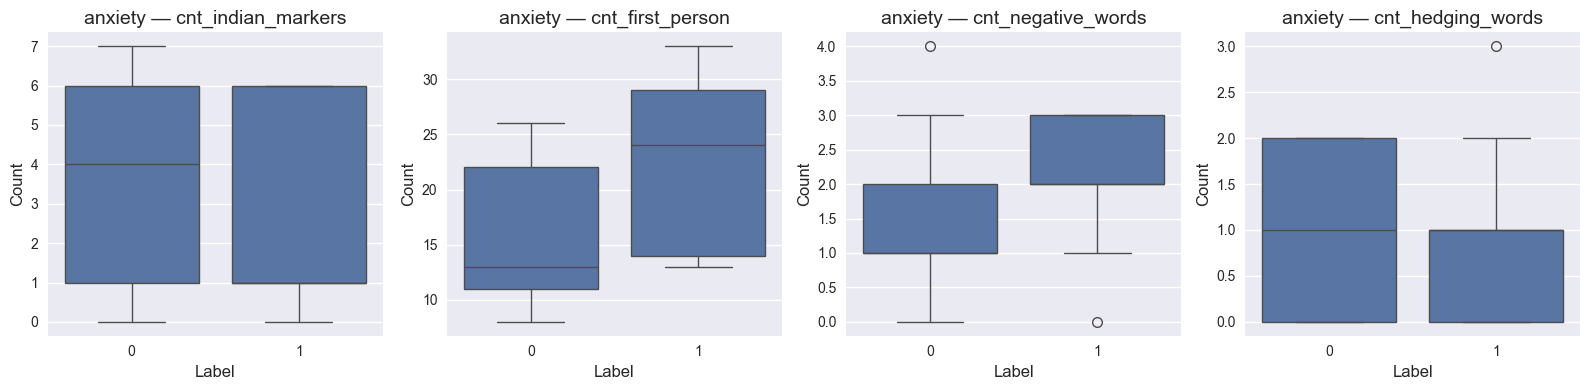

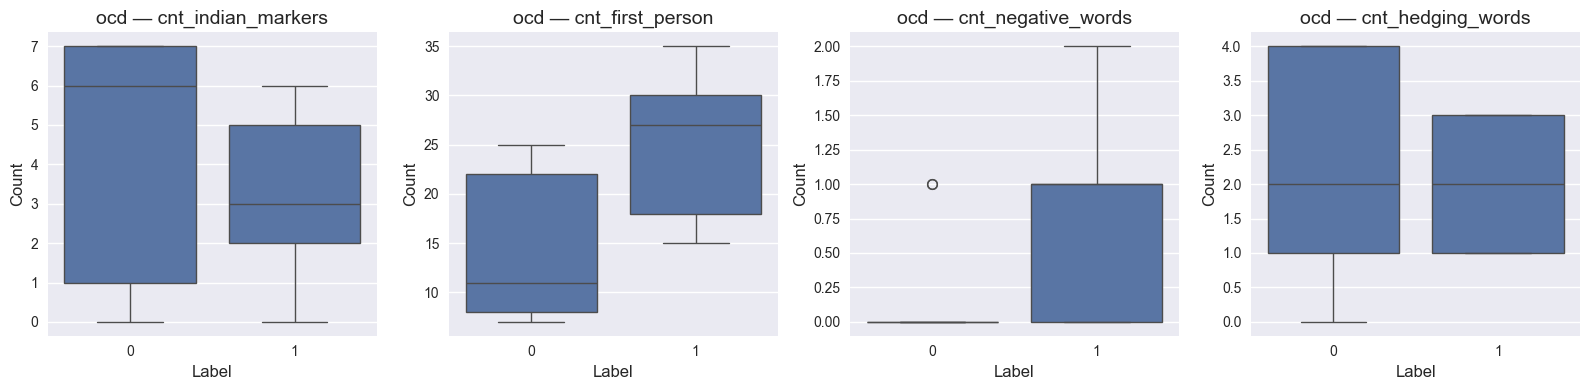

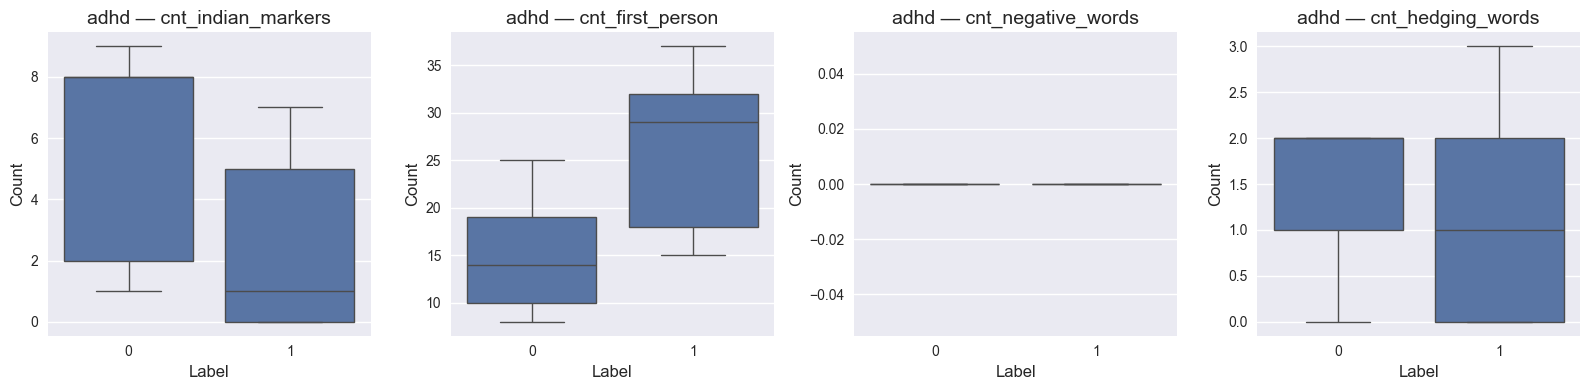

Correlation of linguistic features with label (overall):
  cnt_indian_markers  : -0.1035
  cnt_first_person    : 0.5555
  cnt_negative_words  : 0.3203
  cnt_hedging_words   : 0.1060


In [8]:
# 3e. Linguistic pattern analysis

indian_markers = {"umm", "hmm", "only", "itself", "na", "no", "actually", "basically"}
first_person_pronouns = {"i", "me", "my", "myself"}
negative_words = {
    "hopeless", "useless", "tired", "drained", "worthless", "pointless", "empty", "blank",
    "shame", "guilt", "burden", "fail", "failure", "fear", "worry", "scared",
}
hedging_words = {"maybe", "perhaps", "sometimes", "kinda", "kind", "sort", "sort of", "i think", "i feel"}


def count_markers(text: str, vocab: set[str]) -> int:
    tokens = tokenize(text)
    return sum(1 for t in tokens if t in vocab)


def count_phrase_occurrences(text: str, phrases: set[str]) -> int:
    text_l = str(text).lower()
    count = 0
    for ph in phrases:
        if " " in ph:
            count += text_l.count(ph)
    return count


# Per-sample counts in combined answers
df["cnt_indian_markers"] = df["answers_combined"].fillna("").apply(lambda x: count_markers(x, indian_markers))
df["cnt_first_person"] = df["answers_combined"].fillna("").apply(lambda x: count_markers(x, first_person_pronouns))
df["cnt_negative_words"] = df["answers_combined"].fillna("").apply(lambda x: count_markers(x, negative_words))

# Hedging: word-level + phrase-level
df["cnt_hedging_words"] = df["answers_combined"].fillna("").apply(lambda x: count_markers(x, hedging_words) + count_phrase_occurrences(x, hedging_words))

linguistic_cols = [
    "cnt_indian_markers",
    "cnt_first_person",
    "cnt_negative_words",
    "cnt_hedging_words",
]

# Box plots grouped by label per disease
for disease in DISEASES:
    sub = df[df["disease"] == disease]
    if sub.empty:
        continue
    fig, axes = plt.subplots(1, len(linguistic_cols), figsize=(4 * len(linguistic_cols), 4), sharey=False)
    if len(linguistic_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, linguistic_cols):
        sns.boxplot(data=sub, x="label", y=col, ax=ax)
        ax.set_title(f"{disease} — {col}")
        ax.set_xlabel("Label")
        ax.set_ylabel("Count")
    plt.tight_layout()
    plt.show()

# Correlation of each linguistic feature with label (Pearson)
correlations = {}
for col in linguistic_cols:
    if df[col].nunique() > 1:
        corr = df[[col, "label"]].corr().iloc[0, 1]
    else:
        corr = np.nan
    correlations[col] = float(corr) if corr is not None else None

eda_stats["linguistic_feature_correlations"] = correlations

print("Correlation of linguistic features with label (overall):")
for feat, corr in correlations.items():
    print(f"  {feat:20s}: {corr:.4f}" if corr == corr else f"  {feat:20s}: NaN")

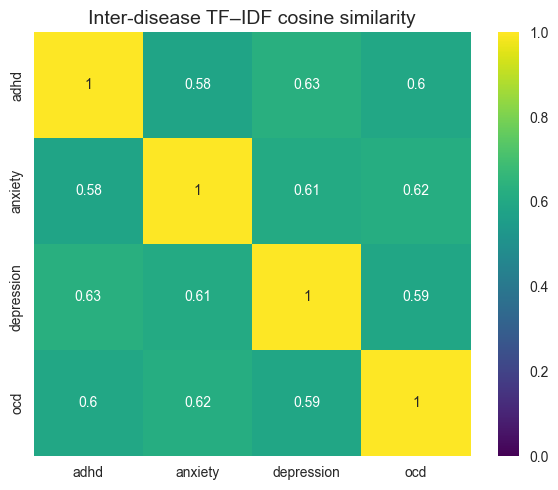

Most similar disease pairs (by cosine similarity):
  adhd vs depression: 0.630
  anxiety vs ocd: 0.618
  anxiety vs depression: 0.606
  adhd vs ocd: 0.597
  depression vs ocd: 0.594
  adhd vs anxiety: 0.583


In [10]:
# 3f. Inter-disease text similarity (TF–IDF + cosine similarity)

texts = df["answers_combined"].fillna("").tolist()

vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(texts)

# ✅ Fix: convert pandas Series mask → numpy array before indexing sparse matrix
mean_vectors = {}
for disease in DISEASES:
    mask = (df["disease"] == disease).to_numpy()  # <-- KEY FIX
    if mask.sum() == 0:
        continue
    mean_vec = X[mask].mean(axis=0)
    mean_vectors[disease] = mean_vec

# Build matrix for cosine similarity
disease_list = sorted(mean_vectors.keys())
mat = np.vstack([np.asarray(mean_vectors[d].A1) for d in disease_list])

sim_matrix = cosine_similarity(mat)

sim_df = pd.DataFrame(sim_matrix, index=disease_list, columns=disease_list)
eda_stats["inter_disease_tfidf_similarity"] = sim_df.to_dict()

plt.figure(figsize=(6, 5))
sns.heatmap(sim_df, annot=True, cmap="viridis", vmin=0, vmax=1)
plt.title("Inter-disease TF–IDF cosine similarity")
plt.tight_layout()
plt.show()

print("Most similar disease pairs (by cosine similarity):")
triu_indices = np.triu_indices_from(sim_matrix, k=1)
flat = []
for i, j in zip(*triu_indices):
    flat.append((disease_list[i], disease_list[j], sim_matrix[i, j]))
for d1, d2, score in sorted(flat, key=lambda x: -x[2]):
    print(f"  {d1} vs {d2}: {score:.3f}")

## Section 4 — Text Cleaning and Normalization

We now define a **cleaning pipeline** applied to all answer columns that:
- lowercases text
- removes extra whitespace and newlines
- removes special characters except basic punctuation (`. , ? ! '`)
- normalizes repeated characters (e.g. `soooo` → `soo` or `so`)
- keeps `umm`, `hmm` as-is (linguistically meaningful)
- expands common abbreviations: `dont`→`don't`, `cant`→`can't`, `wont`→`won't`
- strips leading/trailing whitespace
- replaces empty strings with `[NO RESPONSE]`.

We will then recompute word-count statistics and compare **before vs after** cleaning with a few side-by-side examples.

In [11]:
# 4a. Cleaning pipeline

ABBREVIATIONS = {
    "dont": "don't",
    "cant": "can't",
    "wont": "won't",
}

# Keep these tokens as-is
KEEP_TOKENS = {"umm", "hmm"}


def normalize_repeated_chars(text: str, max_repeats: int = 2) -> str:
    # Collapse character repetitions beyond max_repeats
    def _repl(match):
        char = match.group(1)
        return char * max_repeats

    return re.sub(r"(.)\1{" + str(max_repeats) + r",}", _repl, text)


def clean_text(text: str) -> str:
    if not isinstance(text, str):
        text = ""

    original = text

    # Lowercase
    text = text.lower()

    # Expand abbreviations at token level
    tokens = text.split()
    expanded_tokens = []
    for t in tokens:
        core = re.sub(r"[^a-z']", "", t)
        if core in ABBREVIATIONS:
            expanded_tokens.append(ABBREVIATIONS[core])
        else:
            expanded_tokens.append(t)
    text = " ".join(expanded_tokens)

    # Normalize repeated characters
    text = normalize_repeated_chars(text)

    # Remove special characters except basic punctuation (. , ? ! ')
    text = re.sub(r"[^a-z0-9\s\.,\?!']+", " ", text)

    # Remove extra whitespace and newlines
    text = re.sub(r"\s+", " ", text).strip()

    # Re-introduce [NO RESPONSE] for empty
    if text == "":
        text = "[NO RESPONSE]"

    return text


# Apply cleaning to all answer columns and keep originals for comparison
for col in answer_cols:
    df[f"{col}_original"] = df[col]
    df[col] = df[col].apply(clean_text)

# Recompute combined answers after cleaning
df["answers_combined_clean"] = df[answer_cols].agg(" ".join, axis=1).str.strip()

# 4b. Re-run word count stats after cleaning
for col in answer_cols:
    df[f"{col}_words_clean"] = df[col].apply(lambda x: len(str(x).split()))

df["combined_words_clean"] = df["answers_combined_clean"].apply(lambda x: len(str(x).split()))

stats_before = df.groupby("disease")["combined_words"].agg(["min", "max", "mean", "median", "std"]).round(2)
stats_after = df.groupby("disease")["combined_words_clean"].agg(["min", "max", "mean", "median", "std"]).round(2)

comparison = stats_before.join(stats_after, lsuffix="_before", rsuffix="_after")

eda_stats["text_length_before_after_cleaning"] = comparison.to_dict(orient="index")

print("Word count statistics before vs after cleaning (combined answers):")
display(comparison)

# 4c. Show 3 examples of before vs after
examples = df[[
    "sample_id",
    "disease",
    "answers_combined",
    "answers_combined_clean",
]].sample(n=min(3, len(df)), random_state=SEED)

print("\nExamples of cleaning (before vs after):")
display(examples)

Word count statistics before vs after cleaning (combined answers):


,min_before,max_before,mean_before,median_before,std_before,min_after,max_after,mean_after,median_after,std_after
disease,,,,,,,,,,
adhd,110,273,189.50,203.0,61.81,110,274,190.05,203.0,61.90
anxiety,96,225,163.09,183.5,51.32,96,225,163.09,184.0,51.28
depression,85,231,156.74,170.0,42.33,85,231,157.36,171.0,42.59
ocd,82,252,174.59,193.5,62.34,82,252,175.05,195.0,62.49



Examples of cleaning (before vs after):


,sample_id,disease,answers_combined,answers_combined_clean
83,OCD_012,ocd,I sometimes think about my patients after part...,i sometimes think about my patients after part...
4,DEP_005,depression,I am in 12th standard and my parents keep comp...,i am in 12th standard and my parents keep comp...
42,DEP_043,depression,"Umm, my husband and I had a big fight about mo...","umm, my husband and i had a big fight about mo..."


## Section 5 — Text Construction for BERT

We construct three variants of input text for each sample:
- **Version A — answers_only**: `answer_1 [SEP] answer_2 [SEP] ... answer_5`
- **Version B — qa_pairs**: `Q: question_1 A: answer_1 [SEP] ...`
- **Version C — answers_concatenated**: simple space-joined concatenation of all answers.

These are stored as new columns: `text_v1`, `text_v2`, `text_v3`, and we print a few sample rows for sanity checking.

In [16]:
# 5. Build text versions for BERT

SEP_TOKEN = " [SEP] "

# Version A — answers_only
df["text_v1"] = df.apply(
    lambda row: SEP_TOKEN.join([row[f"answer_{i}"] for i in range(1, 6)]), axis=1
)

# Version B — qa_pairs

def build_qa_pairs(row) -> str:
    parts = []
    for i in range(1, 6):
        q = row.get(f"question_{i}", "") or ""
        a = row.get(f"answer_{i}", "") or ""
        parts.append(f"Q: {q} A: {a}")
    return SEP_TOKEN.join(parts)


df["text_v2"] = df.apply(build_qa_pairs, axis=1)

# Version C — answers_concatenated
df["text_v3"] = df.apply(
    lambda row: " ".join([row[f"answer_{i}"] for i in range(1, 6)]), axis=1
)

print("Sample texts (three versions):")
example = df[[
    "sample_id", "disease", "label", "text_v1", "text_v2", "text_v3"
]].sample(n=1, random_state=SEED)

display(example)

Sample texts (three versions):


,sample_id,disease,label,text_v1,text_v2,text_v3
83,OCD_012,ocd,0,i sometimes think about my patients after part...,Q: Describe thoughts that repeatedly enter you...,i sometimes think about my patients after part...


## Section 6 — Train / Validation / Test Split

We perform a **per-disease stratified split** to preserve class balance:
- For each disease separately, split into:
  - Train: 70%
  - Validation: 15%
  - Test: 15%
- Stratify by `label` **within each disease**.
- Combine per-disease splits back into global train/val/test DataFrames.

We also:
- Print sample counts per split.
- Show label distribution per split, per disease.
- Verify that `sample_id` does not appear in more than one split.
- Save the split indices for downstream use.

In [17]:
# 6. Train / val / test split (per-disease stratified)

train_indices = []
val_indices = []
test_indices = []

for disease in DISEASES:
    sub = df[df["disease"] == disease]
    idx = sub.index
    labels = sub["label"]

    if len(sub) == 0:
        continue

    # First split: train vs temp (val+test)
    train_idx, temp_idx = train_test_split(
        idx,
        test_size=0.30,
        stratify=labels,
        random_state=SKLEARN_RANDOM_STATE,
    )

    # Second split: val vs test (50/50 of temp)
    temp_labels = labels.loc[temp_idx]
    val_idx, test_idx = train_test_split(
        temp_idx,
        test_size=0.50,
        stratify=temp_labels,
        random_state=SKLEARN_RANDOM_STATE,
    )

    train_indices.extend(train_idx.tolist())
    val_indices.extend(val_idx.tolist())
    test_indices.extend(test_idx.tolist())

train_indices = sorted(set(train_indices))
val_indices = sorted(set(val_indices))
test_indices = sorted(set(test_indices))

# Construct splits
df_train = df.loc[train_indices].reset_index(drop=True)
df_val = df.loc[val_indices].reset_index(drop=True)
df_test = df.loc[test_indices].reset_index(drop=True)

# Sanity checks
print("Split sizes:")
print("  Train:", len(df_train))
print("  Val  :", len(df_val))
print("  Test :", len(df_test))

# Label distribution per split per disease
print("\nLabel distribution per split per disease:")

for name, split_df in [("train", df_train), ("val", df_val), ("test", df_test)]:
    crosstab = pd.crosstab(split_df["disease"], split_df["label"], margins=False)
    print(f"\n{name.upper()}:")
    display(crosstab)

# Verify no sample_id overlaps between splits
ids_train = set(df_train["sample_id"])
ids_val = set(df_val["sample_id"])
ids_test = set(df_test["sample_id"])

assert ids_train.isdisjoint(ids_val)
assert ids_train.isdisjoint(ids_test)
assert ids_val.isdisjoint(ids_test)

print("\nSample ID overlap check: PASS (no overlaps across splits)")

split_indices = {
    "train_indices": train_indices,
    "val_indices": val_indices,
    "test_indices": test_indices,
}

eda_stats["split_sizes"] = {
    "train": len(df_train),
    "val": len(df_val),
    "test": len(df_test),
}

Split sizes:
  Train: 80
  Val  : 16
  Test : 20

Label distribution per split per disease:

TRAIN:


label,0,1
disease,,
adhd,6,9
anxiety,6,9
depression,16,19
ocd,6,9



VAL:


label,0,1
disease,,
adhd,1,2
anxiety,1,2
depression,3,4
ocd,1,2



TEST:


label,0,1
disease,,
adhd,2,2
anxiety,2,2
depression,4,4
ocd,2,2



Sample ID overlap check: PASS (no overlaps across splits)


## Section 7 — Tokenization Analysis

We now analyze tokenization behavior for the three text variants using `bert-base-uncased`:
- Tokenize **all samples** (before splitting) for each text version.
- For each version, compute token-length statistics and histograms.
- Report the percentage of samples exceeding token lengths 128, 256, 384, 512.
- Recommend a `max_length` for training based on these statistics.
- Tokenize train/val/test splits using the chosen `max_length` with `padding=max_length`, `truncation=True`, and `return_tensors="pt"`.
- Inspect one tokenized example.

Loading tokenizer...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


Tokenizing full dataset for version: v1_answers_only (text_v1) ...
Token length stats for v1_answers_only:
{
  "min": 107,
  "max": 331,
  "mean": 202.00862068965517,
  "median": 212.0,
  "pct_exceed": {
    "128": 88.79310344827587,
    "256": 18.96551724137931,
    "384": 0.0,
    "512": 0.0
  }
}


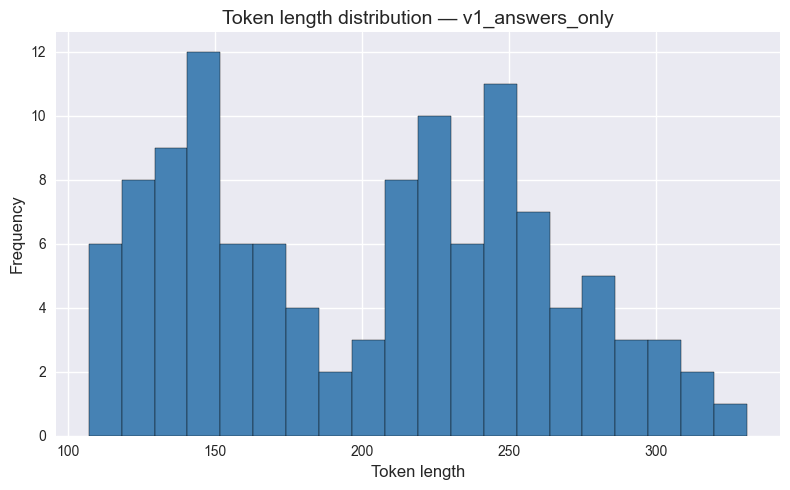


Tokenizing full dataset for version: v2_qa_pairs (text_v2) ...
Token length stats for v2_qa_pairs:
{
  "min": 183,
  "max": 430,
  "mean": 285.9741379310345,
  "median": 288.0,
  "pct_exceed": {
    "128": 100.0,
    "256": 63.793103448275865,
    "384": 6.896551724137931,
    "512": 0.0
  }
}


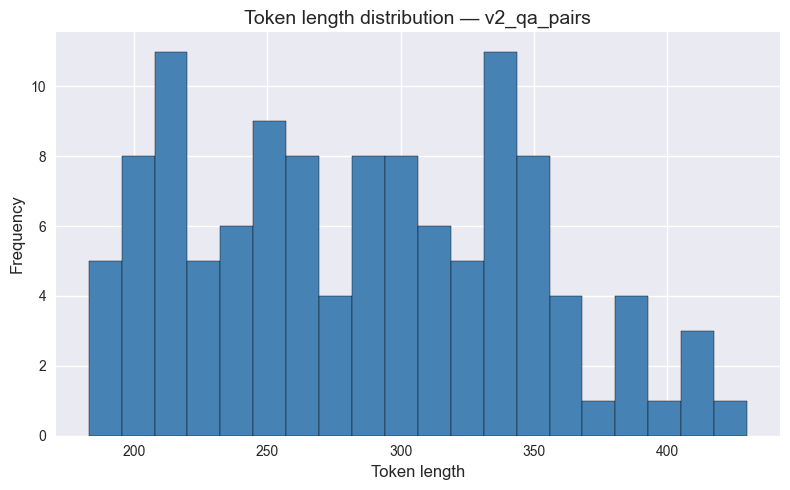


Tokenizing full dataset for version: v3_answers_concat (text_v3) ...
Token length stats for v3_answers_concat:
{
  "min": 103,
  "max": 327,
  "mean": 198.00862068965517,
  "median": 208.0,
  "pct_exceed": {
    "128": 83.62068965517241,
    "256": 17.24137931034483,
    "384": 0.0,
    "512": 0.0
  }
}


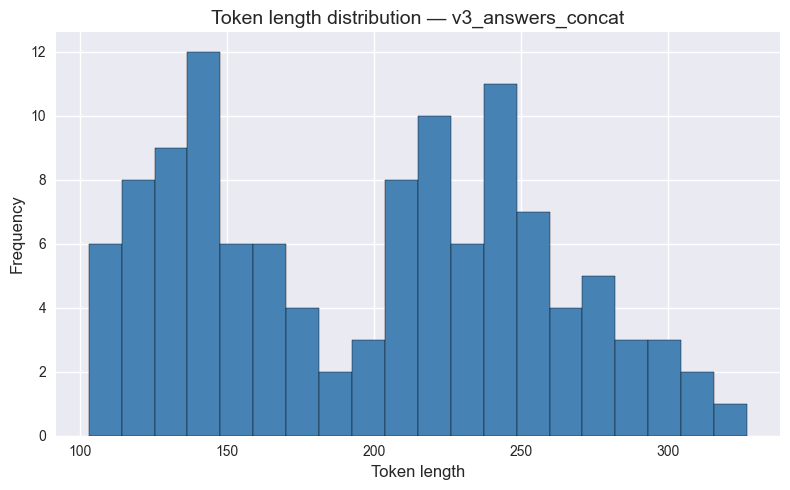


Recommended max_length (based on QA pairs): 512


In [18]:
# 7a. Load BERT tokenizer and analyze token lengths

TOKENIZER_NAME = "bert-base-uncased"

print("Loading tokenizer...")
tokenizer = BertTokenizerFast.from_pretrained(TOKENIZER_NAME)

# Save tokenizer configuration for reuse
tokenizer.save_pretrained(TOKENIZER_DIR)

text_versions = {
    "v1_answers_only": "text_v1",
    "v2_qa_pairs": "text_v2",
    "v3_answers_concat": "text_v3",
}

length_stats = {}

for ver_name, col in text_versions.items():
    print(f"\nTokenizing full dataset for version: {ver_name} ({col}) ...")
    texts = df[col].tolist()
    enc = tokenizer(
        texts,
        padding=False,
        truncation=False,
        add_special_tokens=True,
    )
    lengths = [len(ids) for ids in enc["input_ids"]]
    lengths = np.array(lengths)

    stats = {
        "min": int(lengths.min()),
        "max": int(lengths.max()),
        "mean": float(lengths.mean()),
        "median": float(np.median(lengths)),
    }

    thresholds = [128, 256, 384, 512]
    pct_exceed = {}
    for t in thresholds:
        pct = float((lengths > t).mean() * 100.0)
        pct_exceed[str(t)] = pct

    stats["pct_exceed"] = pct_exceed
    length_stats[ver_name] = stats

    print(f"Token length stats for {ver_name}:")
    print(json.dumps(stats, indent=2))

    # Histogram
    plt.figure(figsize=(8, 5))
    plt.hist(lengths, bins=20, color="steelblue", edgecolor="black")
    plt.title(f"Token length distribution — {ver_name}")
    plt.xlabel("Token length")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

# Choose recommended max_length for training based on version 2 (QA pairs)
qa_stats = length_stats["v2_qa_pairs"]
exceed_256 = qa_stats["pct_exceed"]["256"]
exceed_384 = qa_stats["pct_exceed"]["384"]

if exceed_256 < 5.0:
    RECOMMENDED_MAX_LENGTH = 256
elif exceed_384 < 5.0:
    RECOMMENDED_MAX_LENGTH = 384
else:
    RECOMMENDED_MAX_LENGTH = 512

print("\nRecommended max_length (based on QA pairs):", RECOMMENDED_MAX_LENGTH)

eda_stats["tokenization_length_stats"] = length_stats
eda_stats["recommended_max_length"] = int(RECOMMENDED_MAX_LENGTH)

In [19]:
# 7b. Tokenize train/val/test splits using recommended max_length

BEST_TEXT_COL = "text_v2"  # QA pairs for richer context
MAX_LEN = RECOMMENDED_MAX_LENGTH

print(f"Using text column '{BEST_TEXT_COL}' and max_length={MAX_LEN} for model training encodings.")

enc_train = tokenizer(
    df_train[BEST_TEXT_COL].tolist(),
    padding="max_length",
    truncation=True,
    max_length=MAX_LEN,
    return_tensors="pt",
)

enc_val = tokenizer(
    df_val[BEST_TEXT_COL].tolist(),
    padding="max_length",
    truncation=True,
    max_length=MAX_LEN,
    return_tensors="pt",
)

enc_test = tokenizer(
    df_test[BEST_TEXT_COL].tolist(),
    padding="max_length",
    truncation=True,
    max_length=MAX_LEN,
    return_tensors="pt",
)

print("Train encodings shape:")
print("  input_ids     :", enc_train["input_ids"].shape)
print("  attention_mask:", enc_train["attention_mask"].shape)
if "token_type_ids" in enc_train:
    print("  token_type_ids:", enc_train["token_type_ids"].shape)

# Inspect one example
example_idx = 0
example_ids = enc_train["input_ids"][example_idx]
example_mask = enc_train["attention_mask"][example_idx]

print("\nExample tokenized sample (train[0]):")
print("  input_ids shape     :", example_ids.shape)
print("  attention_mask shape:", example_mask.shape)

decoded = tokenizer.decode(example_ids, skip_special_tokens=False)
print("  decoded sequence    :")
print(decoded)

# Store for later saving
encodings = {
    "train": enc_train,
    "val": enc_val,
    "test": enc_test,
}

Using text column 'text_v2' and max_length=512 for model training encodings.
Train encodings shape:
  input_ids     : torch.Size([80, 512])
  attention_mask: torch.Size([80, 512])
  token_type_ids: torch.Size([80, 512])

Example tokenized sample (train[0]):
  input_ids shape     : torch.Size([512])
  attention_mask shape: torch.Size([512])
  decoded sequence    :
[CLS] q : describe a recent situation that made you feel overwhelmed or hopeless. a : last month i failed my upsc prelims for the third time. my parents spent so much money on coaching. i just sat in my room for days, couldn ' t eat properly. i keep thinking i am a burden on my family and there is no point trying anymore. [SEP] q : how has your energy level affected your daily routine? a : i used to wake up at 6 am for morning walk but now i can ' t even get out of bed before noon. simple tasks like bathing or cooking feel like climbing a mountain. i skip meals, just lie on the bed scrolling phone for hours. [SEP] q : describe

## Section 8 — PyTorch Dataset and DataLoaders

We define a `MentalHealthDataset` class compatible with BERT-style models:
- `__getitem__` returns a dictionary containing:
  - `input_ids`, `attention_mask`, `token_type_ids`
  - `label` (0/1)
  - `disease_label` (0=depression, 1=anxiety, 2=ocd, 3=adhd)
  - `sample_id` (string)
  - `disease` (string)

Then we construct `DataLoader`s:
- `train_loader`: `batch_size=16`, `shuffle=True`
- `val_loader`: `batch_size=16`, `shuffle=False`
- `test_loader`: `batch_size=16`, `shuffle=False`

Finally, we print one batch to verify the shapes and data types.

In [20]:
# 8. PyTorch Dataset and DataLoaders

DISEASE_TO_ID = {"depression": 0, "anxiety": 1, "ocd": 2, "adhd": 3}
ID_TO_DISEASE = {v: k for k, v in DISEASE_TO_ID.items()}


class MentalHealthDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, encodings_dict: dict):
        self.df = dataframe.reset_index(drop=True)
        self.encodings = encodings_dict

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int) -> dict:
        item = {
            "input_ids": self.encodings["input_ids"][idx].long(),
            "attention_mask": self.encodings["attention_mask"][idx].long(),
        }
        if "token_type_ids" in self.encodings:
            item["token_type_ids"] = self.encodings["token_type_ids"][idx].long()
        else:
            # For safety, provide zeros if token_type_ids absent (e.g. some models)
            item["token_type_ids"] = torch.zeros_like(item["input_ids"])

        label = int(self.df.loc[idx, "label"])
        disease_str = str(self.df.loc[idx, "disease"])
        disease_label = DISEASE_TO_ID.get(disease_str, -1)

        item["label"] = torch.tensor(label, dtype=torch.long)
        item["disease_label"] = torch.tensor(disease_label, dtype=torch.long)
        item["sample_id"] = str(self.df.loc[idx, "sample_id"])
        item["disease"] = disease_str
        return item


BATCH_SIZE = 16

train_dataset = MentalHealthDataset(df_train, enc_train)
val_dataset = MentalHealthDataset(df_val, enc_val)
test_dataset = MentalHealthDataset(df_test, enc_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Inspect one batch
batch = next(iter(train_loader))

print("Batch keys:", batch.keys())
for k, v in batch.items():
    if isinstance(v, torch.Tensor):
        print(f"  {k:15s} -> shape {tuple(v.shape)} dtype={v.dtype}")
    else:
        # sample_id / disease (list of strings)
        print(f"  {k:15s} -> length {len(v)} (non-tensor)")

Batch keys: dict_keys(['input_ids', 'attention_mask', 'token_type_ids', 'label', 'disease_label', 'sample_id', 'disease'])
  input_ids       -> shape (16, 512) dtype=torch.int64
  attention_mask  -> shape (16, 512) dtype=torch.int64
  token_type_ids  -> shape (16, 512) dtype=torch.int64
  label           -> shape (16,) dtype=torch.int64
  disease_label   -> shape (16,) dtype=torch.int64
  sample_id       -> length 16 (non-tensor)
  disease         -> length 16 (non-tensor)


## Section 9 — Save Processed Artifacts

We now persist all key preprocessing outputs under `data/processed/text/`:
- `train.pkl`, `val.pkl`, `test.pkl` — processed pandas DataFrames per split.
- `train_encodings.pt`, `val_encodings.pt`, `test_encodings.pt` — tokenized tensors for the chosen text version.
- `label_mappings.json` — mapping dictionaries for disease and label semantics.
- `dataset_stats.json` — all computed EDA statistics and split metadata.
- `tokenizer_config/` — the BERT tokenizer saved earlier.

We also print a summary of written files and their sizes.

In [21]:
# 9. Save processed artifacts

print("Saving processed splits (DataFrames) and encodings...")

train_pkl_path = os.path.join(PROCESSED_TEXT_DIR, "train.pkl")
val_pkl_path = os.path.join(PROCESSED_TEXT_DIR, "val.pkl")
test_pkl_path = os.path.join(PROCESSED_TEXT_DIR, "test.pkl")

enc_train_path = os.path.join(PROCESSED_TEXT_DIR, "train_encodings.pt")
enc_val_path = os.path.join(PROCESSED_TEXT_DIR, "val_encodings.pt")
enc_test_path = os.path.join(PROCESSED_TEXT_DIR, "test_encodings.pt")

label_mappings_path = os.path.join(PROCESSED_TEXT_DIR, "label_mappings.json")
dataset_stats_path = os.path.join(PROCESSED_TEXT_DIR, "dataset_stats.json")

# Save DataFrames
df_train.to_pickle(train_pkl_path)
df_val.to_pickle(val_pkl_path)
df_test.to_pickle(test_pkl_path)

# Save encodings as torch tensors

def encodings_to_save(encodings_dict: dict) -> dict:
    return {k: v.clone().detach() for k, v in encodings_dict.items()}


torch.save(encodings_to_save(enc_train), enc_train_path)
torch.save(encodings_to_save(enc_val), enc_val_path)
torch.save(encodings_to_save(enc_test), enc_test_path)

# Label mappings
label_schema_meta = metadata.get("label_schema", {"0": "not affected", "1": "affected"})

label_mappings = {
    "disease_to_id": DISEASE_TO_ID,
    "id_to_disease": ID_TO_DISEASE,
    "label_to_str": label_schema_meta,
}

with open(label_mappings_path, "w", encoding="utf-8") as f:
    json.dump(label_mappings, f, indent=2)

# Helper for JSON-serializing numpy / pandas values

def _json_default(obj):
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    return str(obj)


# Add metadata and split info to stats
eda_stats["metadata"] = metadata
eda_stats["split_indices"] = split_indices
eda_stats["best_text_column"] = BEST_TEXT_COL

with open(dataset_stats_path, "w", encoding="utf-8") as f:
    json.dump(eda_stats, f, indent=2, default=_json_default)

# List saved files with sizes
print("\nSaved artifacts:")
for path in [
    train_pkl_path,
    val_pkl_path,
    test_pkl_path,
    enc_train_path,
    enc_val_path,
    enc_test_path,
    label_mappings_path,
    dataset_stats_path,
]:
    size_kb = os.path.getsize(path) / 1024.0
    print(f"  {os.path.relpath(path, PROJECT_ROOT):40s} -> {size_kb:8.2f} KB")

Saving processed splits (DataFrames) and encodings...

Saved artifacts:
  data\processed\text\train.pkl            ->   783.72 KB
  data\processed\text\val.pkl              ->   161.13 KB
  data\processed\text\test.pkl             ->   190.40 KB
  data\processed\text\train_encodings.pt   ->   962.17 KB
  data\processed\text\val_encodings.pt     ->   194.15 KB
  data\processed\text\test_encodings.pt    ->   242.16 KB
  data\processed\text\label_mappings.json  ->     0.30 KB
  data\processed\text\dataset_stats.json   ->     8.13 KB


## Section 10 — Final Preprocessing Report

This section summarizes the entire preprocessing pipeline and its outputs:
- Dataset characteristics (sample counts, disease breakdown, label balance).
- Cleaning transformations applied.
- Train/validation/test split sizes.
- Tokenization choice and `max_length` rationale.
- List of artifacts saved under `data/processed/text/`.

This serves as a **ready-to-share report** confirming that the dataset is fully prepared for BERT-based training.

In [22]:
# 10. Final preprocessing report

print("==== FINAL PREPROCESSING REPORT ====\n")

# Dataset summary
total_samples = eda_stats.get("total_samples", len(df))
per_disease = eda_stats.get("per_disease_counts", df["disease"].value_counts().to_dict())
label_overall = eda_stats.get("label_distribution_overall", df["label"].value_counts().to_dict())

print("Dataset:")
print(f"  Total samples      : {total_samples}")
print("  Per disease counts :")
for d, c in per_disease.items():
    print(f"    - {d:10s}: {c}")
print("  Overall label counts:")
for lbl, c in label_overall.items():
    print(f"    - label {lbl}: {c}")

# Cleaning summary
print("\nCleaning:")
print("  Applied lowercasing, whitespace normalization, special-char filtering (except . , ? ! '),")
print("  character repetition normalization, abbreviation expansion (dont/cant/wont), and")
print("  replacement of empty responses with [NO RESPONSE].")

# Splits
split_sizes = eda_stats.get("split_sizes", {"train": len(df_train), "val": len(df_val), "test": len(df_test)})
print("\nSplits:")
print(f"  Train size: {split_sizes['train']}")
print(f"  Val size  : {split_sizes['val']}")
print(f"  Test size : {split_sizes['test']}")

# Tokenization
max_len = eda_stats.get("recommended_max_length", RECOMMENDED_MAX_LENGTH)
print("\nTokenization:")
print(f"  Tokenizer     : {TOKENIZER_NAME}")
print(f"  Text variant  : {BEST_TEXT_COL}")
print(f"  max_length    : {max_len}")
print("  Rationale     : chosen such that <~5% of QA-pair sequences exceed this length, balancing context and efficiency.")

# Artifacts saved
print("\nArtifacts saved under data/processed/text/:")
for fname in [
    "train.pkl",
    "val.pkl",
    "test.pkl",
    "train_encodings.pt",
    "val_encodings.pt",
    "test_encodings.pt",
    "label_mappings.json",
    "dataset_stats.json",
]:
    path = os.path.join(PROCESSED_TEXT_DIR, fname)
    exists = os.path.exists(path)
    size_kb = os.path.getsize(path) / 1024.0 if exists else 0.0
    status = "OK" if exists else "MISSING"
    print(f"  - {fname:20s} [{status}] {size_kb:8.2f} KB")

print("\nTokenizer config directory:")
print(f"  - {os.path.relpath(TOKENIZER_DIR, PROJECT_ROOT)}")

print("\nReadiness: READY FOR TRAINING ✅")

==== FINAL PREPROCESSING REPORT ====

Dataset:
  Total samples      : 116
  Per disease counts :
    - depression: 50
    - anxiety   : 22
    - ocd       : 22
    - adhd      : 22
  Overall label counts:
    - label 1: 66
    - label 0: 50

Cleaning:
  Applied lowercasing, whitespace normalization, special-char filtering (except . , ? ! '),
  character repetition normalization, abbreviation expansion (dont/cant/wont), and
  replacement of empty responses with [NO RESPONSE].

Splits:
  Train size: 80
  Val size  : 16
  Test size : 20

Tokenization:
  Tokenizer     : bert-base-uncased
  Text variant  : text_v2
  max_length    : 512
  Rationale     : chosen such that <~5% of QA-pair sequences exceed this length, balancing context and efficiency.

Artifacts saved under data/processed/text/:
  - train.pkl            [OK]   783.72 KB
  - val.pkl              [OK]   161.13 KB
  - test.pkl             [OK]   190.40 KB
  - train_encodings.pt   [OK]   962.17 KB
  - val_encodings.pt     [OK]   1